### Detecting overlap - case red wine classification 

**This dataset is notorious for being very limited and trashy, also with contradicting trends and overlapping between variables vs. target -variable**

In [ ]:
import pandas as pd
df = pd.read_csv("winequality-red.csv")

### Box plots - very useful for inspecting possible trends towards the target variable!

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_24892\1391991117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')


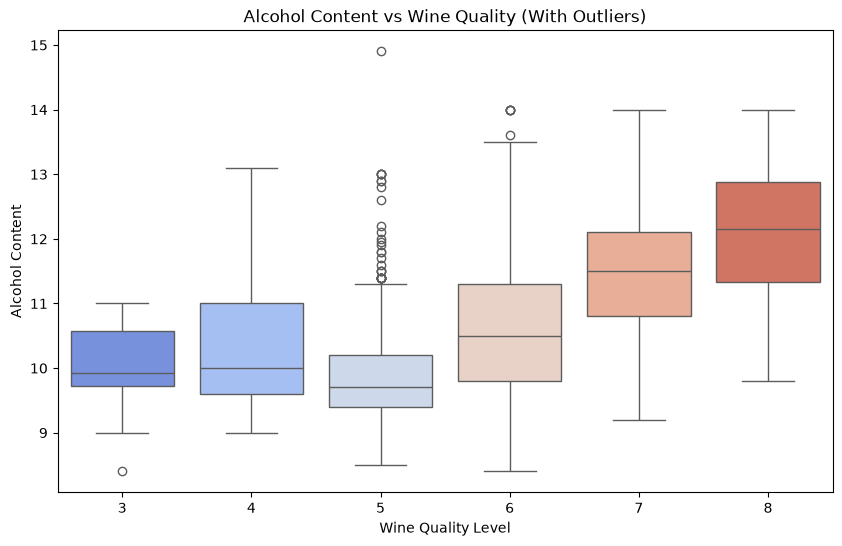

In [2]:
# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

# Example box plot for alcohol content across wine quality levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')
plt.title('Alcohol Content vs Wine Quality (With Outliers)')
plt.xlabel('Wine Quality Level')
plt.ylabel('Alcohol Content')
plt.show()

Here we can see above that generally the alcohol content tend sto increase as the quality level goes up... except quality level 5 (which is consumer average level) seems to be all over the place. This is a contradiction in the main trend, which seems to be an upward curve otherwise. Also many outliers in quality level 5!

In [3]:
# see the target distribution
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [4]:
# total rows
len(df)

1599

We have ~1600 wines in the data

In [5]:
# no missing values it seems
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
# duplicates
df.duplicated().sum()

np.int64(240)

Ooof... 240 duplicate values. This might be a problem in the future.

<Axes: >

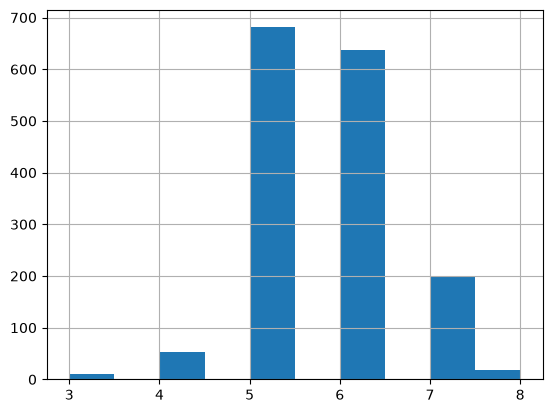

In [7]:
# visualize
df['quality'].hist()

This is a pretty horrible distribution for a target... levels 3 and 4 and practically outliers and levels 7 and 8 are also heavily underrepresented. In addition, since we are aiming this later for a classification model, we would probably want to make this a uniform distribution.

With a bad distribution like this, and having 240 duplicate values, this dataset is going to need some balancing work later.

**Let's inspect 

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_24892\2384726210.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='volatile acidity', data=df, palette='coolwarm')


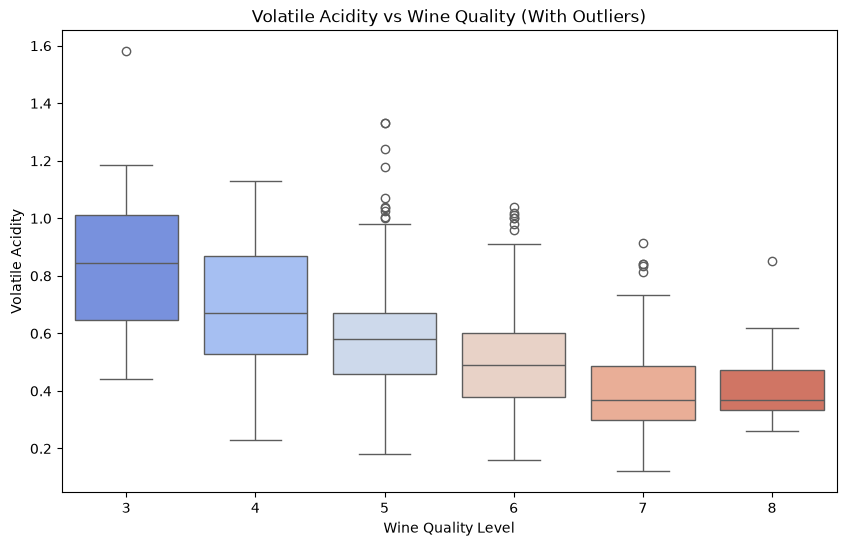

In [8]:
# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

# Example box plot for alcohol content across wine quality levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df, palette='coolwarm')
plt.title('Volatile Acidity vs Wine Quality (With Outliers)')
plt.xlabel('Wine Quality Level')
plt.ylabel('Volatile Acidity')
plt.show()

There seems to be a rough trend: as quality level goes up, volatile acidity tends to go down. Some outliers in the middle quality levels though.

___

### Overlapping: the most challening thing to notice in a dataset

The common way is to use seaborn scatter plots and compare variables. We'll study more advanced methods later also. SHAP is also helpful in this (with the more advanced plots).

**Volatile acidity vs quality level - we can see a considerable overlap in the middle, which means the machine learning model is going to have trouble in deciding between quality levels, when volatile acidity is between 0.3-0.5 and alcohol content is between 9.5 - 11.5 %**

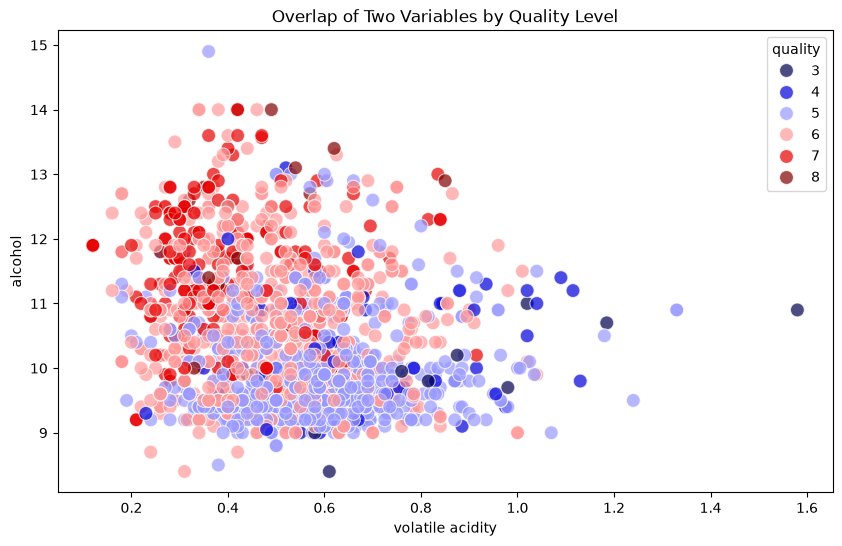

In [9]:
# Plot setup
plt.figure(figsize=(10, 6))

# Scatter plot with hue indicating quality level
sns.scatterplot(x='volatile acidity', y='alcohol', hue='quality', data=df, palette='seismic', s=100, alpha=0.7)

# Add title and labels
plt.title('Overlap of Two Variables by Quality Level')
plt.xlabel('volatile acidity')
plt.ylabel('alcohol')

# Display the plot
plt.show()